# Project: Neural Estate 2026

**Teamleden:**  
-  Haben Sebhatu
- Chris de Nooijer
- Tom Spoler
- Ids Grunstra 

# 1. Opdracht 1: Exploratieve Data Analyse (EDA)

## 1.2 Setup: Libraries importeren

In [29]:
import os
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam  # pyright: ignore[reportMissingImports]
from tensorflow.keras.callbacks import EarlyStopping  # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
# Importeer TensorFlow en Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential  # pyright: ignore[reportMissingImports]
from tensorflow.keras.layers import Dense  # pyright: ignore[reportMissingImports]


## 1.3 Setup: Configuratie en paden

Hieronder stellen we de paden in naar de data en definieren we eenvoudige hulpfuncties voor de exploratieve data-analyse.

In [2]:
# Configuratie: paden naar de datamap
data_dir = "."
train_img_dir = os.path.join(data_dir, "Train")

## 1.4 Beelddata: Afbeeldingen inlezen en tonen

### 1.4.1 Structuur van de afbeeldingen


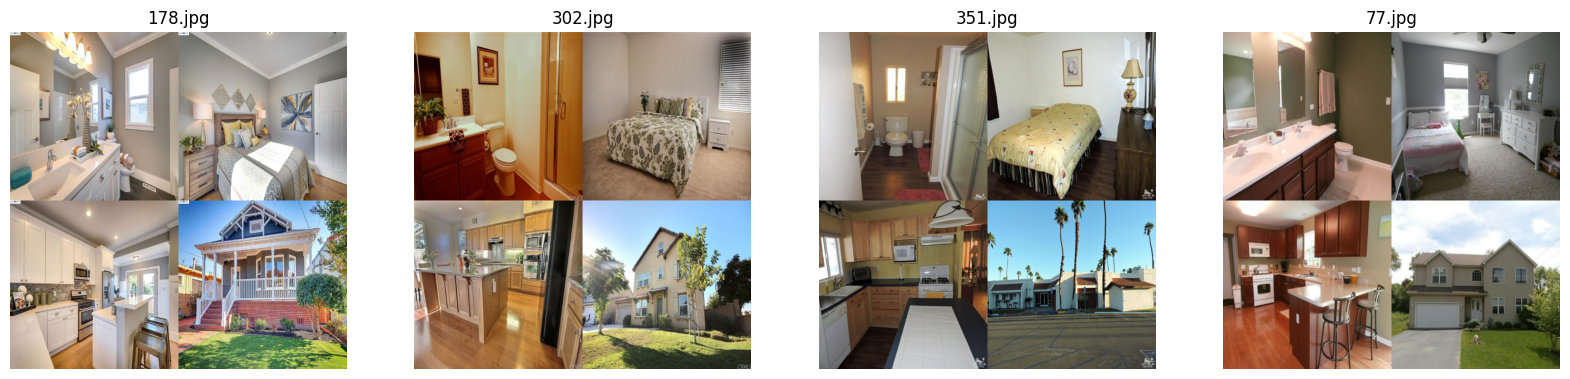

In [3]:
# Lees alle bestanden uit de map Train en kies er 4 willekeurig
train_img_dir = "Train"
image_files = os.listdir(train_img_dir)
sample = random.sample(image_files, 4)

# Maak een plot aan met 4 vakjes naast elkaar
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Loop door de 4 gekozen foto's en laat ze zien
for ax, fname in zip(axes, sample):
    img_path = train_img_dir + "/" + fname
    img = Image.open(img_path)
    
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis("off") # Verberg de assen

plt.show()

Elke afbeelding in de dataset is een samengevoegde collage van 4 foto's van dezelfde woning, 


| Linksboven      | Rechtsboven     |
|-----------------|-----------------|
| Slaapkamer      | Badkamer        |
| Linksonder  | Rechtsonder |
| Keuken          | Vooraanzicht    |

Dit geeft het model visuele informatie over de staat en stijl van de woning vanuit meerdere perspectieven.

- - -
## 1.5 metadata inladen

Het bestand train.csv bevat de metadata van elke woning, zoals oppervlakte, aantal kamers en de doelvariabele **Price**.

In [4]:
# Laad de tabulaire data en print een samenvatting
csv_path = os.path.join(data_dir, "train.csv")
df = pd.read_csv(csv_path)

print("=== Eerste rijen (head) ===")
display(df.head())

print("\n=== Statistische samenvatting (describe) ===")
display(df.describe())

print("\n=== Info & missing values (info) ===")
df.info()

=== Eerste rijen (head) ===


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
0,1,4,4.0,4053,33.6968,-111.8892,869500
1,2,4,3.0,3343,34.8280,-119.0349,865200
2,3,3,4.0,3923,33.7669,-111.9182,889000
3,4,5,5.0,4022,33.7752,-111.7791,910000
4,5,3,4.0,4116,33.7669,-111.9182,971226



=== Statistische samenvatting (describe) ===


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,5.000000e+02
mean,250.500000,3.350000,2.669500,2369.64600,35.128844,-116.469049,5.980218e+05
std,144.481833,1.172283,1.017578,1208.18261,2.386173,6.554434,5.240649e+05
min,1.000000,1.000000,1.000000,701.00000,32.631500,-122.368300,2.200000e+04
25%,125.750000,2.000000,2.000000,1440.00000,33.808200,-119.802500,2.350000e+05
50%,250.500000,3.000000,2.500000,2097.50000,33.920800,-117.609600,5.300000e+05
75%,375.250000,4.000000,3.000000,3104.50000,35.640600,-116.371300,7.490000e+05
max,500.000000,10.000000,7.000000,9583.00000,47.791800,-87.885900,5.858000e+06



=== Info & missing values (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   House ID   500 non-null    int64  
 1   Bedrooms   500 non-null    int64  
 2   Bathrooms  500 non-null    float64
 3   Area       500 non-null    int64  
 4   Latitude   500 non-null    float64
 5   Longitude  500 non-null    float64
 6   Price      500 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 27.5 KB


- - -
## 1.6 Visualisaties

### 1.6.1 Scatterplot: Oppervlakte vs. Prijs

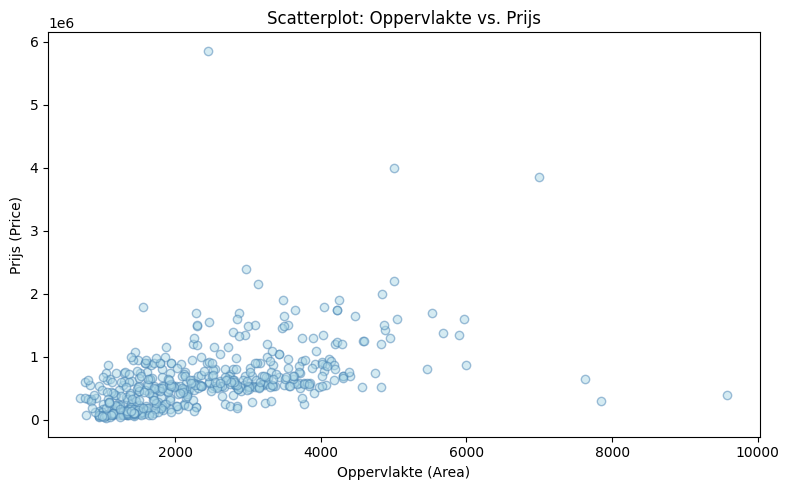

In [5]:
# Scatterplot: Oppervlakte vs. Prijs
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df["Area"],
    df["Price"],
    alpha=0.5,
    edgecolors="steelblue",
    facecolors="lightblue",
)
ax.set_xlabel("Oppervlakte (Area)")
ax.set_ylabel("Prijs (Price)")
ax.set_title("Scatterplot: Oppervlakte vs. Prijs")
plt.tight_layout()
plt.show()

### Bevindingen

Positieve trend: Over het algemeen geldt hoe groter het huis, hoe hoger de verkoopprijs.

De grote massa: De meeste huizen zijn kleiner dan 4000 vierkante voet en kosten minder dan 1,5 miljoen dollar.

Opvallende uitschieters: Er is bijvoorbeeld een relatief klein huis  van bijna 6 miljoen dollar en een gigantisch huis  dat relatief goedkoop is.

Conclusie: Oppervlakte is een belangrijke voorspeller, maar om de prijs echt goed te schatten heeft ons model straks absoluut ook de andere gegevens nodig (zoals locatie en de foto's).

_ _ _

### 1.6.2 Boxplots: Slaapkamers & Badkamers vs. Prijs

/var/folders/g0/p5b6twgd2tjcxdld4y2xrks00000gn/T/ipykernel_63549/2688868026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Bedrooms", y="Price", ax=axes[0], palette="Blues")
/var/folders/g0/p5b6twgd2tjcxdld4y2xrks00000gn/T/ipykernel_63549/2688868026.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Bathrooms", y="Price", ax=axes[1], palette="Greens")


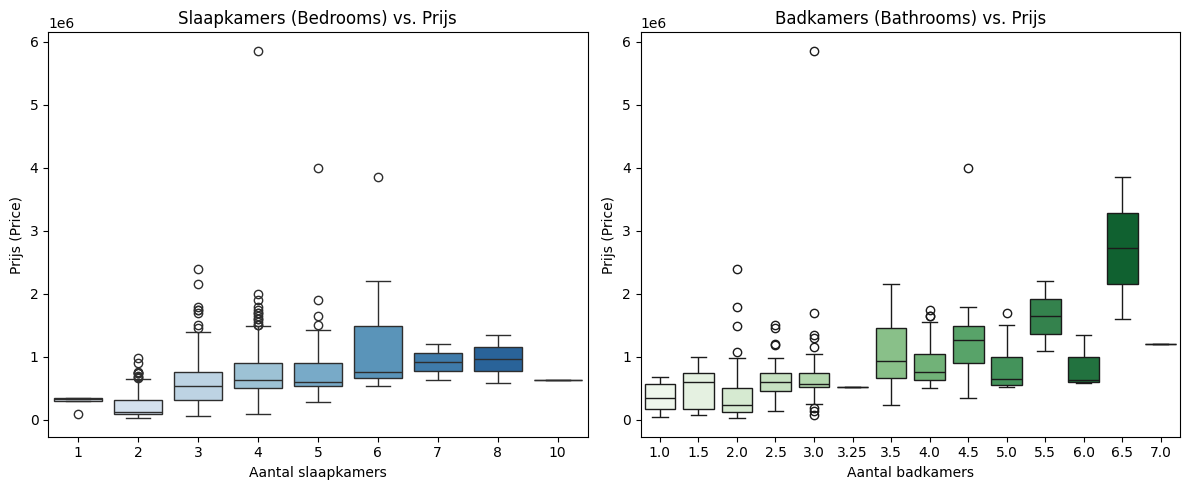

In [6]:
# Boxplots: Slaapkamers & Badkamers vs. Prijs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Bedrooms", y="Price", ax=axes[0], palette="Blues")
axes[0].set_title("Slaapkamers (Bedrooms) vs. Prijs")
axes[0].set_xlabel("Aantal slaapkamers")
axes[0].set_ylabel("Prijs (Price)")

sns.boxplot(data=df, x="Bathrooms", y="Price", ax=axes[1], palette="Greens")
axes[1].set_title("Badkamers (Bathrooms) vs. Prijs")
axes[1].set_xlabel("Aantal badkamers")
axes[1].set_ylabel("Prijs (Price)")

plt.tight_layout()
plt.show()

### Bevindingen

**Relatie Slaapkamers en Prijs:** Er is een duidelijke stijgende lijn te zien in de gemiddelde prijs bij huizen van 2 tot en met 6 slaapkamers. Opvallend is dat bij huizen met nog meer slaapkamers 7 of meer de prijs juist weer afvlakt. Ook zien we heel veel uitschieters.

**Relatie Badkamers en Prijs:** Bij de badkamers is de stijgende trend over de hele linie eigenlijk nog iets sterker. Vooral vanaf 3,5 badkamers begint de prijs flink op te lopen. Ook hier is een uitschieter in de categorie met 3 badkamers.

**Conclusie:** Meer kamers betekent meestal een duurder huis, maar het aantal badkamers lijkt een net iets sterkere voorspeller voor huizen in het dure segment dan het aantal slaapkamers. De grote hoeveelheid uitschieters (rondjes boven de boxen) bevestigt opnieuw dat deze variabelen samen met de oppervlakte, locatie en foto's gecombineerd moeten worden voor een echt accuraat model.


- - -
### 1.6.3 Geografische spreiding van woningprijzen

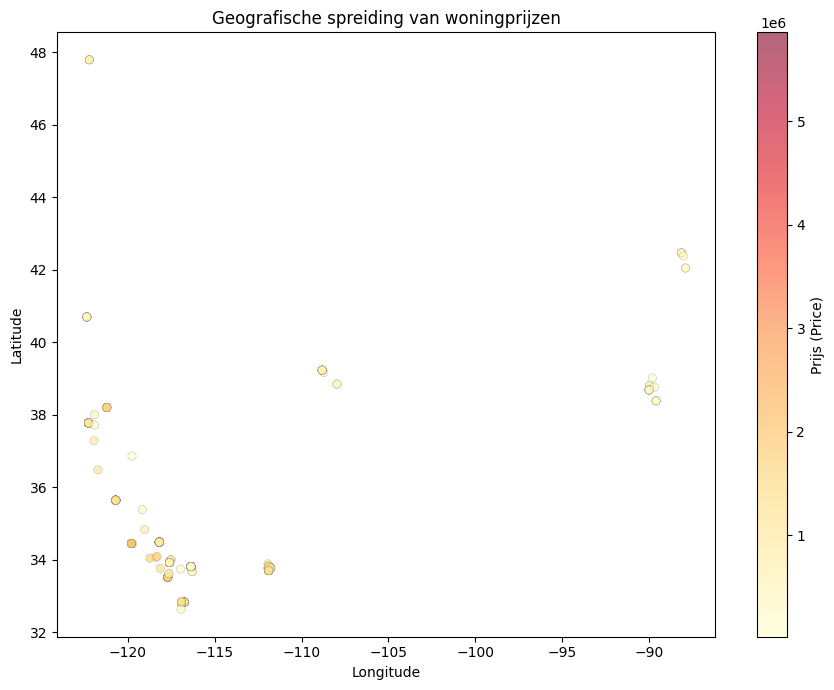

In [7]:
# Geografische scatterplot: Longitude vs. Latitude, gekleurd op Prijs
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["Price"],
    cmap="YlOrRd",
    alpha=0.6,
    edgecolors="grey",
    linewidths=0.3,
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Prijs (Price)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geografische spreiding van woningprijzen")
plt.tight_layout()
plt.show()

Geografische clusters: De huizen in onze dataset zijn niet gelijkmatig verspreid, maar liggen in heel duidelijke groepen. We zien een hele grote concentratie aan de linkerkant  en een paar kleinere plukjes verder naar het oosten. Er zit een enorm leeg gebied tussenin.

Prijs en locatie: De meeste stippen zijn lichtgeel, wat overeenkomt met de grote massa huizen onder de 1,5 miljoen dollar die we al eerder zagen. maar we zien  in de drukke clusters linksonder ook wat donkerdere oranje stippen opduiken.


- - -
### 1.6.4 Correlatie-heatmap

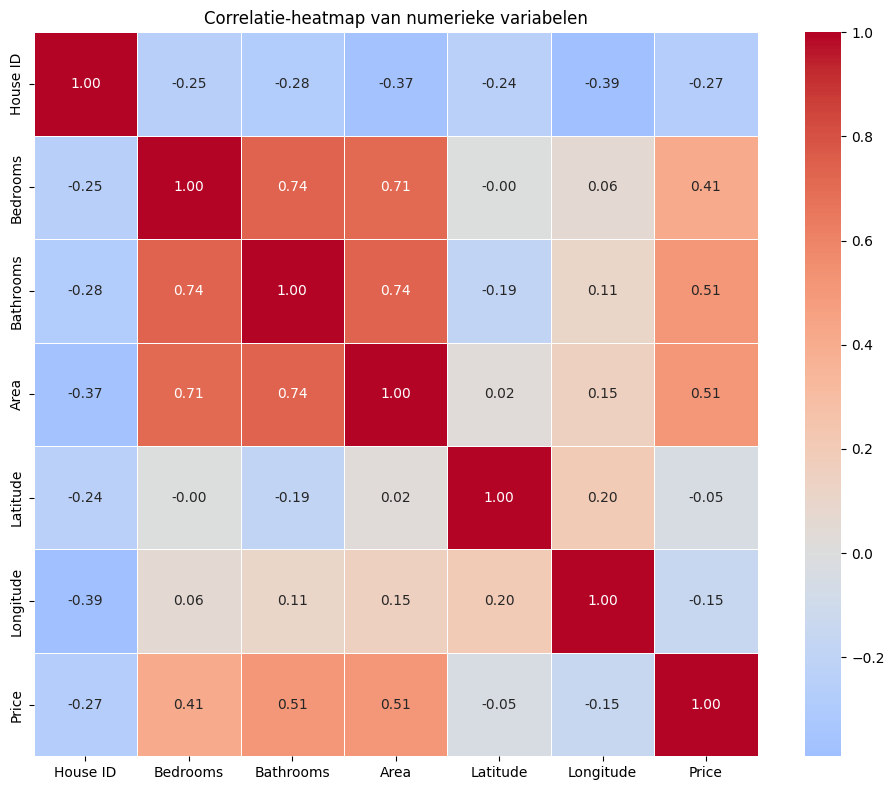

In [8]:
# Correlatie-heatmap van alle numerieke variabelen
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlatie-heatmap van numerieke variabelen")
plt.tight_layout()
plt.show()

Belangrijkste voorspellers: De oppervlakte  en het aantal badkamers  hebben de sterkste positieve correlatie met de verkoopprijs beide 0.51. Direct daarna volgt het aantal slaapkamers 0.41. Dit bevestigt dat de grootte en het aantal kamers belangrijke factoren zijn voor een hogere prijs.

Onderlinge samenhang: Er is een sterke samenhang te zien tussen de variabelen Area, Bathrooms en Bedrooms correlaties tussen de 0.71 en 0.74. 

Locatie: De lengte en breedtegraad  tonen vrijwel geen lineaire correlatie met de prijs -0.15 en -0.05. Dit betekent niet dat locatie onbelangrijk is, maar wel dat de relatie complexer is.



_ _ _
# 2. Opdracht 2: Fully-connected neuraal netwerk



- - -
### 2.1 Data Voorbereiding 

We gebruiken uitsluitend de tabulaire features uit train.csv:

- Features (X): Bedrooms, Bathrooms, Area, Latitude, Longitude
- Target (y): Price

De data wordt opgesplitst in een trainset (80 %) en een validatieset (20 %).  
Daarna schalen we de features met StandardScaler. Dit is cruciaal voor neurale netwerken:  
zonder schaling kunnen grote waarden bijv. Area de gradiëntafdaling verstoren en het  
trainen vertragen of instabiel maken.

In [9]:

# 1. Bepaal de features (X) en de target (y)
# We gebruiken de variabelen die we in de EDA hebben geanalyseerd
X = df[['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']]
y = df['Price']

# 2. Splits de data (80% trainen, 20% valideren)
# random_state=42 zorgt ervoor dat we altijd dezelfde willekeurige split krijgen
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Schaal de data
scaler = StandardScaler()

# fit_transform leert de schaal van de trainingsdata en past deze toe
X_train_scaled = scaler.fit_transform(X_train)

# transform past DEZELFDE schaal toe op de validatiedata (zodat we niet 'spieken' in de testdata)
X_val_scaled = scaler.transform(X_val)

# Print even de vorm (shape) om te checken of het goed is gegaan
print(f"Trainingsdata vorm (aantal huizen, aantal features): {X_train_scaled.shape}")
print(f"Validatiedata vorm (aantal huizen, aantal features): {X_val_scaled.shape}")

Trainingsdata vorm (aantal huizen, aantal features): (400, 5)
Validatiedata vorm (aantal huizen, aantal features): (100, 5)


- - -
## 2.2 Modelarchitectuur Bouwen

In [13]:
# !pip install "protobuf<4.0.0"

In [32]:
# Bouw het sequentiële model op
model_tabular = Sequential(name="Tabular_Dense_Network")

# Laag 1: Input en eerste verborgen laag (64 neuronen)
model_tabular.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],), name="Verborgen_Laag_1"))

# Laag 2: Tweede verborgen laag (32 neuronen)
model_tabular.add(Dense(128, activation='relu', name="Verborgen_Laag_2"))

model_tabular.add(Dense(64, activation='relu', name="Verborgen_Laag_3"))

# Laag 3: Output laag (1 neuron, lineaire activatie voor regressie)
model_tabular.add(Dense(1, activation='linear', name="Output_Prijs"))

# Toon een overzicht van het opgebouwde model in de output


- - -
## 2.3 Visualisatie van de Architectuur

In [33]:
model_tabular.summary()

Model: "Tabular_Dense_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Verborgen_Laag_1 (Dense)        │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Verborgen_Laag_2 (Dense)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Verborgen_Laag_3 (Dense)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Prijs (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,753 (167.00 KB)

 Trainable params: 42,753 (167.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Sla het model op als een bestandje op je computer
model_tabular.save('tabular_model.keras')

![Mijn Model](model_netwerk.png)

Screenshot 2026-03-11 at 14.41.30.png

- - -
### 2.4 Onderbouwing van Keuzes


Voor de architectuur van dit fully-connected netwerk hebben we de volgende keuzes gemaakt:

Aantal lagen en neuronen: We hebben het netwerk gebouwd als een soort trechter. We beginnen breed met 256 neuronen, gaan dan naar 128, en ten slotte naar 64. Dit geeft het model genoeg denkkracht om slimme patronen te ontdekken zoals hoe locatie en oppervlakte samenwerken. Omdat de lagen steeds kleiner worden, dwingen we het model om de informatie steeds verder samen te vatten. Dit helpt ook om te voorkomen dat het model de data blind uit zijn hoofd leert (overfitting).

Activeringsfuncties: In de verborgen lagen gebruiken we de ReLU functie. Dit is een bekende en snelle rekenmethode die het model heel goed helpt om complexe, niet-rechte verbanden te snappen. Voor de allerlaatste laag (de output) gebruiken we een Linear functie. Dit is logisch, want we willen een exact geldbedrag in dollars voorspellen, en die prijs mag aan het einde niet door een wiskundige formule in elkaar gedrukt of vervormd worden.

Trainingsepochs: We geven het model de ruimte om maximaal 500 rondes (epochs) te trainen, maar we gebruiken hierbij een slimme rem genaamd Early Stopping. Dit betekent dat het model net zo lang doorleert totdat hij merkt dat de foutmarge niet meer daalt. Zoals we in de grafiek zagen, stopt hij dan automatisch (ruim voor de 500 rondes) en bewaart hij stiekem de gewichten van zijn allerbeste ronde voor ons.

- - -
### 2.5 Keuze voor Lossfunctie en Optimizer

### Waarom MAPE de meest geschikte lossfunctie is

MAPE (Mean Absolute Percentage Error) berekent de fout in procenten in plaats van in harde dollars. Dit is perfect voor huizen, omdat de prijzen in onze dataset enorm verschillen (van $22.000 tot bijna $6 miljoen). Een voorspellingsfout van $50.000 is een enorme misser bij een goedkoop huis van $100.000, maar valt nauwelijks op bij een luxe villa van $3 miljoen. Doordat MAPE puur naar procenten kijkt, weegt het model dit automatisch op een eerlijke manier af.

---

### Hoe de Adam optimizer werkt

Adam is als het ware de 'leraar' van ons model en gebruikt twee slimme trucjes om soepel te leren:

1. Vaart houden (Momentum): Het model onthoudt in welke richting het de vorige keren succesvol heeft geleerd en blijft die kant op bewegen. Hierdoor stuitert en zigzagt het model veel minder tijdens het trainen.
2. Aangepaste leersnelheid: Adam geeft elk onderdeel (parameter) in het netwerk zijn eigen leersnelheid. Onderdelen die al vaak zijn aangepast nemen kleinere, voorzichtigere stapjes. Onderdelen die nog weinig hebben geleerd mogen juist wat grotere stappen nemen.

Deze combinatie zorgt ervoor dat het model heel snel en stabiel leert, wat Adam de absolute standaard maakt voor neurale netwerken.

---

### Keuze van het aantal epochs 

We geven het model de tijd om maximaal 500 rondes (epochs) te trainen. We gebruiken hierbij wel een slimme rem genaamd Early Stopping. Als de foutmarge 30 rondes achter elkaar niet meer verbetert (patience = 30), stopt het trainen automatisch. Het model spoelt dan netjes terug om de gewichten van zijn allerbeste ronde te bewaren.

- - -
### 2.6 Model Compileren en Trainen

Start met slim trainen...


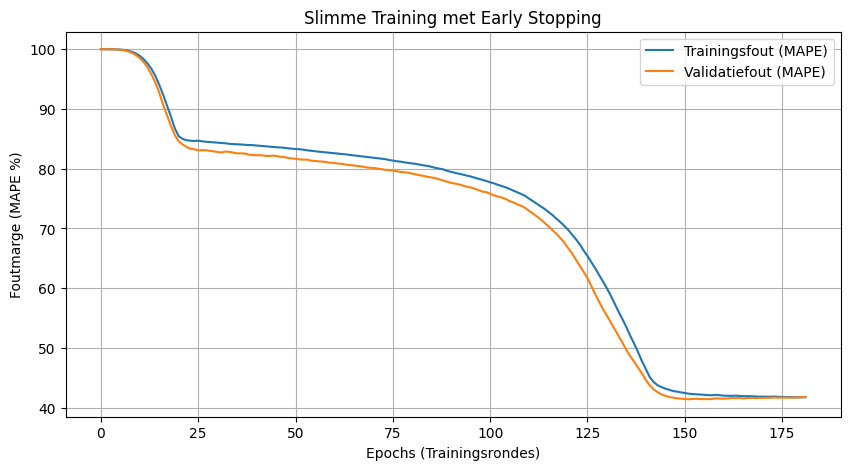

Uiteindelijke Validatie MAPE score: 0.42
Het model is automatisch gestopt na 182 epochs.


In [ ]:
custom_adam = Adam(learning_rate=1e-3)
model_tabular.compile(optimizer=custom_adam, loss='mean_absolute_percentage_error')

# 2. De Redder in Nood: Early Stopping
# Dit stopt de training als hij 30 rondes lang niet meer verbetert, 
# EN hij spoelt automatisch terug naar de allerbeste ronde!
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=30, 
    restore_best_weights=True
)

# 3. Train het model met de nieuwe 'rem'
print("Start met slim trainen...")
history = model_tabular.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500, 
    batch_size=32,
    callbacks=[early_stop], # Hier voegen we onze rem toe
    verbose=0 
)

# 4. Plot het trainingsproces
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Trainingsfout (MAPE)')
plt.plot(history.history['val_loss'], label='Validatiefout (MAPE)')
plt.title('Slimme Training met Early Stopping')
plt.xlabel('Epochs (Trainingsrondes)')
plt.ylabel('Foutmarge (MAPE %)')
plt.legend()
plt.grid(True)
plt.show()

# Print de uiteindelijke score
eind_mape = history.history['val_loss'][-1]
print(f"Uiteindelijke Validatie MAPE score: {eind_mape / 100:.2f}")
print(f"Het model is automatisch gestopt na {len(history.history['loss'])} epochs.")